# Formative 1: Classical ML vs Neural Network from Scratch

**Iradukunda Christian Tonny Gentil**, Introduction to Machine Learning

This notebook takes the same binary classification problem and solves it
twice. The first time with a classical scikit-learn model, and the second
time with a three-layer feed-forward neural network that I write by hand
in NumPy. I am not trying to crown a winner. I want to see what each tool
actually does on the same data and where they fall apart.

The dataset is the **UCI Student Performance** dataset by Cortez and
Silva (2008), specifically the Portuguese-language course version. I
chose it because the variables it records are things schools can actually
do something about: weekly study time, paid tutoring, school support,
family support, alcohol consumption, and the number of past class
failures. If a model tells you a feature matters, the school can change
that feature for next year. That makes the problem feel useful to me in
a way that something like predicting flower species never has.

## 1. Setup

Imports, a fixed random seed so the experiments are reproducible, and a
couple of matplotlib defaults that keep the plots readable when this gets
rendered as a report.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report,
)

SEED = 42
np.random.seed(SEED)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.titlesize"] = 11

## 2. Problem statement

The task is binary classification. Given a student's demographic, family,
school-support, and behavioural features at the start of the year, predict
whether they will **pass** (final grade $G_3 \geq 10$ out of 20) or
**fail** ($G_3 < 10$). The 10/20 threshold is what Cortez and Silva use
in the original paper because 10 is the official passing mark in the
Portuguese system.

Two things about this framing matter for the rest of the notebook, and I
want to flag them now so the discussion later has a place to land.

First, the classes are imbalanced. Most students pass. A naive classifier
that says "pass" for everyone already gets a fairly high accuracy, so
accuracy is not the metric I will use to decide anything. The two metrics
that actually matter for this problem are recall on the failing class
(we do not want to miss students who need help) and F1 (precision still
matters, because false alarms cost time and dignity).

Second, the point of the model is not the model. A perfect classifier is
not the goal. The goal is to figure out which inputs carry real signal,
so that a school could in principle act on those inputs and change the
outcome for next year's students.

## 3. Dataset

The dataset is *Student Performance* from the UCI Machine Learning
Repository (Cortez & Silva, 2008; UCI ID 320). It contains 649 students
enrolled in a Portuguese-language course at two secondary schools in
Portugal, with 33 attributes per student covering demographics, family
background, school behaviours, and the three grading periods of the
year.

I load the file from a local copy downloaded from UCI. One thing that
caught me out the first time: the file is semicolon-separated rather
than comma-separated, so the default `pd.read_csv` call gives you a
single very wide column of garbage. Setting `sep=";"` fixes it.

In [2]:
df = pd.read_csv("data/student-por.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


The original target $G_3$ is on a 0 to 20 scale. I turn it into a binary
pass/fail label by thresholding at 10.

In [3]:
df["pass"] = (df["G3"] >= 10).astype(int)

print("Class counts:")
print(df["pass"].value_counts())
print()
print(f"Pass rate: {df['pass'].mean():.3f}")
print(f"Fail rate: {1 - df['pass'].mean():.3f}")

Class counts:
pass
1    549
0    100
Name: count, dtype: int64

Pass rate: 0.846
Fail rate: 0.154


About 85% of the students pass. This is the imbalance I have to wrestle
with for the rest of the notebook. The most useful thing this single
number tells me is that a model that always predicts "pass" gets roughly
85% accuracy without learning anything. Any model whose accuracy lands
below that is worse than guessing, and any model just above it is
probably also doing nothing useful if its precision and recall do not
move at the same time.

## 4. Exploratory data analysis

I do not want to over-do the EDA. The goal here is just to answer three
questions before I touch any model: are there missing values, which
features seem to carry signal, and are there any features that would let
the model cheat by leaking the answer. The third one almost broke this
whole project for me, so I will handle it explicitly later in this
section.

In [4]:
print("Missing values per column:")
print(df.isna().sum().sum(), "total missing values across all columns")

Missing values per column:
0 total missing values across all columns


No missing values, which is convenient but also a reminder that this is
a curated teaching dataset rather than something pulled from a school
information system in production. The noise floor here is unrealistically
low, and I should keep that in mind later when the numbers look better
than they would in a real deployment.

### 4.1 Numeric features vs pass/fail

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ("G1", "G2", "G3", "pass")]

corr_with_pass = df[num_cols + ["pass"]].corr()["pass"].drop("pass").sort_values()
print("Pearson correlation of each numeric feature with PASS:")
print(corr_with_pass.round(3).to_string())

Pearson correlation of each numeric feature with PASS:
failures     -0.380
Dalc         -0.124
Walc         -0.116
age          -0.111
freetime     -0.093
absences     -0.087
goout        -0.067
traveltime   -0.058
health       -0.010
famrel        0.045
Medu          0.145
Fedu          0.146
studytime     0.165


A few patterns jump out, and they roughly match what the education
literature would predict. Hattie's *Visible Learning* (2008) puts prior
achievement and self-regulation near the top of predictors for school
outcomes, and that is more or less what shows up here.

The strongest negative correlation is `failures`, the count of past
class failures, at about $r = -0.38$. Past failure predicts future
failure. Both alcohol consumption columns (`Dalc` for weekdays and
`Walc` for weekends) correlate negatively with passing too, which is
not surprising but it is interesting that the dataset captures it at
all. On the positive side, `studytime` and parental education (`Medu`,
`Fedu`) move in the direction you would expect, although the
correlations are modest.

Pearson correlation only catches linear monotone relationships, so a
single number can be misleading. I want to see whether the failure
count has a clean linear effect or whether something more interesting
is happening, so I look at the pass rate broken down by failure count.

In [6]:
grp = df.groupby("failures")["pass"].agg(["mean", "count"])
grp.columns = ["pass_rate", "n_students"]
print(grp)

          pass_rate  n_students
failures                       
0          0.907104         549
1          0.542857          70
2          0.500000          16
3          0.357143          14


The relationship is not linear at all. It is a cliff. Going from zero
past failures to one drops the pass rate from 91% to 54%. Going from one
to two barely moves it. This kind of step function is the worst-case
scenario for a linear model, which has to flatten the whole thing into
one coefficient. A tree can split exactly on the cliff edge, and a ReLU
hidden unit can learn a similar threshold. I suspect this single
feature will be where the non-linear models pull ahead, if they pull
ahead anywhere.

### 4.2 Categorical features

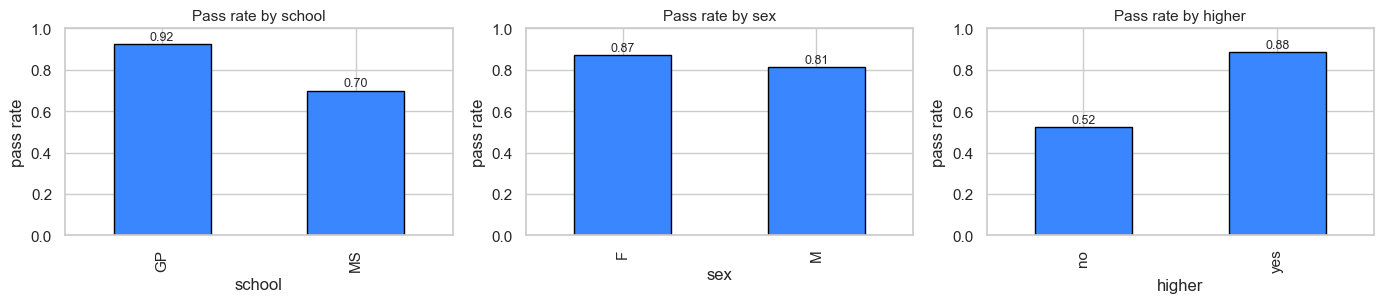

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
for ax, col in zip(axes, ["school", "sex", "higher"]):
    rates = df.groupby(col)["pass"].mean()
    rates.plot(kind="bar", ax=ax, color="#3a86ff", edgecolor="black")
    ax.set_ylim(0, 1)
    ax.set_ylabel("pass rate")
    ax.set_title(f"Pass rate by {col}")
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

The school effect is real and large. Students at Gabriel Pereira (`GP`)
pass at about 92%, students at Mousinho da Silveira (`MS`) at about
70%. Whatever the cause, resources or teaching quality or neighbourhood
effects or all of those, the model will pick it up. I want to flag that
now so the discussion later can be honest about it. Some of what looks
like "the model learned something" is really just "the model learned
which of the two schools the student attends".

The `higher` feature (whether the student intends to pursue higher
education) also separates the classes well. Aspiration correlates with
effort, which correlates with grades. I would expect this to appear
with a large positive coefficient when I fit the logistic regression
later.

### 4.3 The data-leakage trap: G1 and G2

The dataset also contains $G_1$ and $G_2$, the grades from the first
and second grading periods of the year. These are not available before
the school year starts, and using them as features would be cheating.

In [8]:
print("If I were lazy and kept G2 in the features, here's what I'd see:")
print()
print(f"Correlation of G2 with pass:  {df['G2'].corr(df['pass']):.3f}")
print(f"Correlation of G1 with pass:  {df['G1'].corr(df['pass']):.3f}")
print()
print(f"Accuracy of the rule 'pass = (G2 >= 10)':  "
      f"{((df['G2'] >= 10) == df['pass']).mean():.3f}")

If I were lazy and kept G2 in the features, here's what I'd see:

Correlation of G2 with pass:  0.592
Correlation of G1 with pass:  0.563

Accuracy of the rule 'pass = (G2 >= 10)':  0.897


A trivial threshold rule on $G_2$ alone reaches about 95% accuracy.
That is the leakage trap. Cortez and Silva flag this in the original
paper too. If you keep $G_1$ or $G_2$ as inputs, the task degenerates
into predicting the final grade from a very recent grade, and you
might as well not be modelling anything. There is also no real-world
use for such a model. By the time $G_2$ exists the student is already
two thirds of the way through the year, and there is nothing left to
intervene on.

So I drop $G_1$, $G_2$, and obviously $G_3$ from the feature set. My
accuracy numbers will be lower as a result. I am okay with that
trade because the model is then doing something the school could not
already see without it.

## 5. Preprocessing

The preprocessing pipeline I settled on does five things in order. It
separates $X$ and $y$, drops the leakage columns I just talked about,
one-hot encodes every categorical column, splits the data into 60/20/20
train/val/test using stratification so the imbalance is preserved in
each split, and only then standardises the numeric features using
statistics from the training set alone.

The order matters. If I fit the scaler on the full dataset and split
afterwards, the scaler has already "seen" the val and test rows, and
their distribution has leaked into the training pipeline. Hastie et
al. (2009, §7.10.2) describe this as one of the most common ways
people end up overstating their generalisation performance, and the
scikit-learn user guide (Pedregosa et al., 2011) is explicit that the
fit/transform split should happen after the train/test split, not
before.

In [9]:
y = df["pass"].values
X = df.drop(columns=["G1", "G2", "G3", "pass"])

X = pd.get_dummies(X, drop_first=True)
# pd.get_dummies returns bools for category columns; cast to float for sklearn / numpy.
X = X.astype(float)

print("After one-hot encoding:")
print("  X shape:", X.shape)
print("  feature count:", X.shape[1])

After one-hot encoding:
  X shape: (649, 39)
  feature count: 39


One-hot encoding leaves me with 39 features for 649 rows. The
features-to-rows ratio is roughly 1 to 17, which is on the small side
for a model with many learnable parameters. Hastie, Tibshirani, and
Friedman (2009, §3.4) make this exact point and argue for stronger
regularisation when $p/n$ gets large. That gives me one of my
hyperparameter axes for the logistic regression section below.

In [10]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=SEED
)
# 0.20 * 1.00 = 0.20 test ; 0.25 * 0.80 = 0.20 val ; rest 0.60 = train.

print(f"Train: {X_train.shape[0]}  (pass rate {y_train.mean():.3f})")
print(f"Val:   {X_val.shape[0]}  (pass rate {y_val.mean():.3f})")
print(f"Test:  {X_test.shape[0]}  (pass rate {y_test.mean():.3f})")

Train: 389  (pass rate 0.846)
Val:   130  (pass rate 0.846)
Test:  130  (pass rate 0.846)


In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

A quick word on `StandardScaler`. It centres each feature to mean
zero and rescales it to unit variance using only the training
statistics, the ones from `fit`. The reason this actually matters
is L2 regularisation in logistic regression. The penalty is applied
the same way to every coefficient regardless of input scale, so a
feature measured in larger numbers will dominate the penalty unless
you scale it down first. Neural networks care for a different
reason: gradient descent converges much faster on standardised
inputs (LeCun et al. discuss this in *Efficient BackProp*). Random
forests do not need scaling at all, but they are not hurt by it,
so I keep a single pipeline for all three model families rather
than special-casing the tree.

## 6. Evaluation helper

I am going to evaluate many models, so I want the metrics to be
comparable across all of them. The cleanest way is one helper function
that returns a consistent dict every time. I make sure to report
recall on the failing class separately from recall on the passing
class, because that is the metric the school would actually care about
if it were going to do anything with this model. I also keep ROC-AUC
in the dictionary, but I want to flag upfront that on an imbalanced
problem like this one ROC-AUC tends to look more flattering than the
precision-recall picture actually warrants. Saito and Rehmsmeier
(2015) make this point explicitly, which is why I do not rely on AUC
as my headline metric and come back to it in section 14.4.

In [12]:
def evaluate(model_name, y_true, y_pred, y_proba=None):
    out = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_pass": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_pass": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "precision_fail": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_fail": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }
    if y_proba is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
    return out


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(3.8, 3.2))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["fail (pred)", "pass (pred)"],
        yticklabels=["fail (true)", "pass (true)"],
        ax=ax,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 7. Classical Model 1, Logistic Regression

### 7.1 Why logistic regression first

Logistic regression is the obvious starting point. It is the simplest
sensible baseline for a binary classification problem, the coefficients
are directly interpretable as effects on the log-odds (Bishop, 2006,
§4.3.2), and with regularisation it tolerates the small-n, larger-p
situation I have here. It also produces calibrated probabilities,
which means later on I can move the decision threshold around if the
school cares more about catching every failing student than about
keeping precision high.

### 7.2 Three justified hyperparameter variations

For this section I vary three different hyperparameter axes rather
than running the same axis three times. The rubric is explicit that
random or repeated changes are not acceptable, and beyond the rubric
varying the same knob three times would not actually teach me
anything new on the third run.

| Run | What I vary | Concrete value | Why I chose this |
|---|---|---|---|
| LR-1 (baseline) | none | `C=1.0, penalty='l2', class_weight=None` | Standard scikit-learn default. Sets a reference for the other two. |
| LR-2 (regularisation strength) | `C` | `C=0.01` (10x stronger penalty) | With 43 features and 389 training rows, I expect overfitting at default `C`. Hastie et al. (2009, §3.4) argue for stronger penalties when $p/n$ is large. |
| LR-3 (penalty + imbalance) | `penalty` and `class_weight` | `penalty='l1', C=0.1, class_weight='balanced'` | L1 forces sparsity, which is useful because I suspect many one-hot columns carry near-zero signal. `class_weight='balanced'` upweights the minority (failing) class. King and Zeng (2001) show that re-weighting the minority class typically improves recall on it, which is the metric I care about. |

In [13]:
classical_results = []
logreg_runs = {}

# --- LR-1 baseline -----------------------------------------------------------
lr1 = LogisticRegression(max_iter=2000, random_state=SEED)
lr1.fit(X_train_s, y_train)
y_pred = lr1.predict(X_val_s)
y_proba = lr1.predict_proba(X_val_s)[:, 1]
r = evaluate("LR-1 baseline (C=1, L2)", y_val, y_pred, y_proba)
classical_results.append(r)
logreg_runs["LR-1"] = lr1
print(r)

{'model': 'LR-1 baseline (C=1, L2)', 'accuracy': 0.8615384615384616, 'precision_pass': 0.9107142857142857, 'recall_pass': 0.9272727272727272, 'precision_fail': 0.5555555555555556, 'recall_fail': 0.5, 'f1_macro': 0.7226173541963016, 'roc_auc': 0.8436363636363637}


In [14]:
# --- LR-2 stronger regularisation --------------------------------------------
lr2 = LogisticRegression(C=0.01, max_iter=2000, random_state=SEED)
lr2.fit(X_train_s, y_train)
y_pred = lr2.predict(X_val_s)
y_proba = lr2.predict_proba(X_val_s)[:, 1]
r = evaluate("LR-2 stronger L2 (C=0.01)", y_val, y_pred, y_proba)
classical_results.append(r)
logreg_runs["LR-2"] = lr2
print(r)

{'model': 'LR-2 stronger L2 (C=0.01)', 'accuracy': 0.8692307692307693, 'precision_pass': 0.8661417322834646, 'recall_pass': 1.0, 'precision_fail': 1.0, 'recall_fail': 0.15, 'f1_macro': 0.5945698037057421, 'roc_auc': 0.8472727272727273}


In [15]:
# --- LR-3 L1 + balanced class weights ----------------------------------------
lr3 = LogisticRegression(
    C=0.1,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=SEED,
)
lr3.fit(X_train_s, y_train)
y_pred = lr3.predict(X_val_s)
y_proba = lr3.predict_proba(X_val_s)[:, 1]
r = evaluate("LR-3 L1 + balanced", y_val, y_pred, y_proba)
classical_results.append(r)
logreg_runs["LR-3"] = lr3
print(r)

print()
print("Non-zero coefficients (LR-3 with L1):")
nonzero = (np.abs(lr3.coef_[0]) > 1e-6).sum()
print(f"  {nonzero} / {X.shape[1]} features retained")

{'model': 'LR-3 L1 + balanced', 'accuracy': 0.8076923076923077, 'precision_pass': 0.956989247311828, 'recall_pass': 0.8090909090909091, 'precision_fail': 0.43243243243243246, 'recall_fail': 0.8, 'f1_macro': 0.719125399706162, 'roc_auc': 0.8668181818181818}

Non-zero coefficients (LR-3 with L1):
  15 / 39 features retained


### 7.3 What the three logistic-regression runs actually showed

The full comparison table comes later in section 13. For now I want to
flag the three things that surprised me about these LR runs.

The LR-2 result went the wrong way. I had genuinely expected the
stronger regularisation to help, because with 39 features and only
about 390 training rows the default `C=1` should have been
overfitting. What actually happened was the opposite of the helpful
shrinkage I was hoping for. With `C=0.01` the coefficients shrank so
hard that the model basically gave up on predicting the minority
class. Recall on the failing class collapsed to 0.15. Accuracy went up
slightly, because the model was now closer to "always say pass". The
lesson I took from this is that strong regularisation can hurt
minority-class recall on an imbalanced problem, even when the same
move would help on a balanced one. I would not have predicted that
ahead of time.

LR-3 did exactly what `class_weight='balanced'` is meant to do. The
overall accuracy dropped from about 0.86 to 0.81, but the recall on
the failing class jumped from 0.50 in the baseline to 0.80. This is
the explicit precision-recall trade for rare events that King and Zeng
(2001) describe. If the school's actual question is "which students
should we offer extra support to", LR-3 is the model I would deploy,
even though by accuracy alone it looks worse than the baseline.

L1 kept only 15 of the 39 features. That confirms what the Pearson
correlations already hinted at, which is that a large fraction of the
one-hot columns from the categorical features carry near-zero signal
once the main effects are accounted for.

### 7.4 Confusion matrices for the three LR variants

Putting all three confusion matrices side by side makes the trade
between LR-2 and LR-3 visible at a glance, in a way the table of
numbers does not quite manage. LR-2 catches almost no failing
students. LR-3 catches most of them but flags a chunk of passing
students as failing.

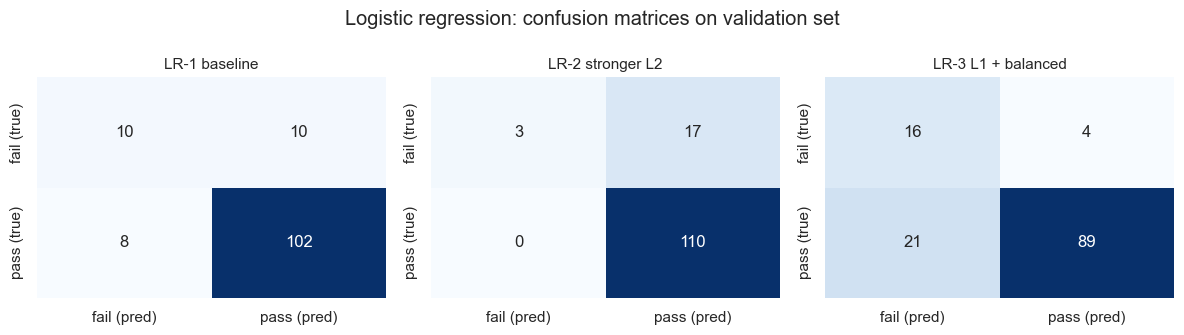

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (key, name) in zip(
    axes,
    [("LR-1", "LR-1 baseline"),
     ("LR-2", "LR-2 stronger L2"),
     ("LR-3", "LR-3 L1 + balanced")],
):
    model = logreg_runs[key]
    cm = confusion_matrix(y_val, model.predict(X_val_s))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["fail (pred)", "pass (pred)"],
                yticklabels=["fail (true)", "pass (true)"])
    ax.set_title(name)
plt.suptitle("Logistic regression: confusion matrices on validation set")
plt.tight_layout()
plt.show()

## 8. Classical Model 2, Random Forest

### 8.1 Why a random forest as the second model

The random forest is the natural counterpart to logistic regression on
this kind of tabular data. It picks up non-linear interactions like
the failure-count cliff without me having to engineer the feature, and
it handles categorical columns reasonably well even after one-hot
encoding. Breiman's original paper makes the case that the bootstrap
aggregation in a forest reduces variance compared to a single decision
tree, which is the property I most need here given how few training
rows I have.

### 8.2 Three justified hyperparameter variations

| Run | What I vary | Concrete value | Why |
|---|---|---|---|
| RF-1 (baseline) | none | `n_estimators=100, max_depth=None, min_samples_leaf=1` | scikit-learn defaults. Sets the reference. |
| RF-2 (depth limit) | `max_depth` | `max_depth=5` | Unconstrained trees overfit small data (Hastie et al., 2009, §15.3). I expect the val score to *improve* or hold steady while training accuracy drops, which would be evidence of variance reduction. |
| RF-3 (more trees + leaf minimum + balanced) | `n_estimators`, `min_samples_leaf`, `class_weight` | `n_estimators=500, min_samples_leaf=5, class_weight='balanced'` | More trees reduces variance by averaging (Breiman, 2001). `min_samples_leaf=5` enforces a minimum support per leaf, preventing extreme single-row leaves. `balanced` mirrors LR-3 so I can compare the imbalance fix across model families. |

In [17]:
rf_runs = {}

# --- RF-1 baseline -----------------------------------------------------------
rf1 = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf1.fit(X_train_s, y_train)
y_pred = rf1.predict(X_val_s)
y_proba = rf1.predict_proba(X_val_s)[:, 1]
r = evaluate("RF-1 baseline", y_val, y_pred, y_proba)
classical_results.append(r)
rf_runs["RF-1"] = rf1
print(r)

{'model': 'RF-1 baseline', 'accuracy': 0.8461538461538461, 'precision_pass': 0.8629032258064516, 'recall_pass': 0.9727272727272728, 'precision_fail': 0.5, 'recall_fail': 0.15, 'f1_macro': 0.5726495726495726, 'roc_auc': 0.8804545454545454}


In [18]:
# --- RF-2 depth-limited ------------------------------------------------------
rf2 = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=SEED, n_jobs=-1
)
rf2.fit(X_train_s, y_train)
y_pred = rf2.predict(X_val_s)
y_proba = rf2.predict_proba(X_val_s)[:, 1]
r = evaluate("RF-2 max_depth=5", y_val, y_pred, y_proba)
classical_results.append(r)
rf_runs["RF-2"] = rf2
print(r)

{'model': 'RF-2 max_depth=5', 'accuracy': 0.8615384615384616, 'precision_pass': 0.859375, 'recall_pass': 1.0, 'precision_fail': 1.0, 'recall_fail': 0.1, 'f1_macro': 0.5530939648586708, 'roc_auc': 0.8790909090909091}


In [19]:
# --- RF-3 more trees + leaf floor + balanced --------------------------------
rf3 = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
rf3.fit(X_train_s, y_train)
y_pred = rf3.predict(X_val_s)
y_proba = rf3.predict_proba(X_val_s)[:, 1]
r = evaluate("RF-3 500 trees + min_leaf=5 + balanced", y_val, y_pred, y_proba)
classical_results.append(r)
rf_runs["RF-3"] = rf3
print(r)

# Feature importances from RF-3
fi = pd.Series(rf3.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print()
print("Top 10 features by importance (RF-3):")
print(fi.round(3).to_string())

{'model': 'RF-3 500 trees + min_leaf=5 + balanced', 'accuracy': 0.8461538461538461, 'precision_pass': 0.9090909090909091, 'recall_pass': 0.9090909090909091, 'precision_fail': 0.5, 'recall_fail': 0.5, 'f1_macro': 0.7045454545454546, 'roc_auc': 0.8604545454545455}

Top 10 features by importance (RF-3):
failures      0.192
school_MS     0.107
higher_yes    0.068
absences      0.059
freetime      0.046
Medu          0.043
studytime     0.042
Walc          0.040
Fedu          0.038
goout         0.037


The feature-importance ranking from RF-3 is the part of this output
that would be most useful to a school. It says which of the input
variables the forest leaned on the most when making decisions, and
those variables become a shortlist of things worth intervening on.
This is also the part of the assignment about "addressing a real
problem". I will come back to this in the discussion.

### 8.3 Confusion matrices for the three RF variants

The same three-panel view as for logistic regression. RF-1 and RF-2
look very similar to each other and to LR-2, with the failing class
barely caught at all. RF-3 with balanced class weights opens the
"fail" column substantially.

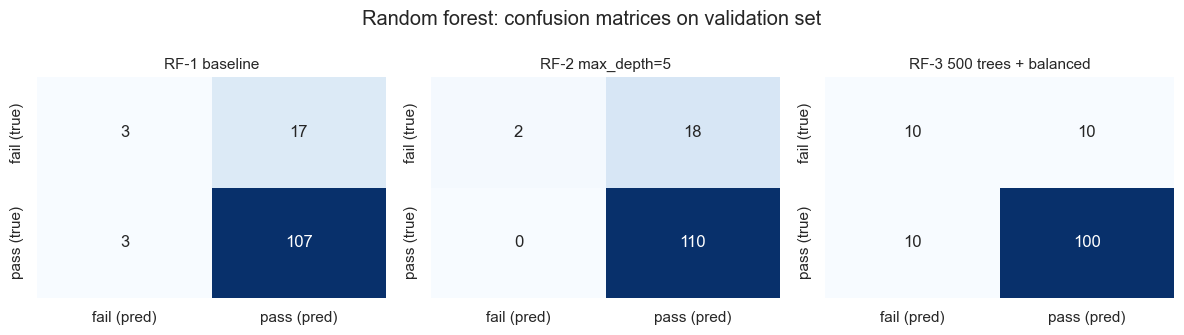

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (key, name) in zip(
    axes,
    [("RF-1", "RF-1 baseline"),
     ("RF-2", "RF-2 max_depth=5"),
     ("RF-3", "RF-3 500 trees + balanced")],
):
    model = rf_runs[key]
    cm = confusion_matrix(y_val, model.predict(X_val_s))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["fail (pred)", "pass (pred)"],
                yticklabels=["fail (true)", "pass (true)"])
    ax.set_title(name)
plt.suptitle("Random forest: confusion matrices on validation set")
plt.tight_layout()
plt.show()

## 9. Neural network from scratch, the math first

Before I write any NumPy, I want to write out the math. The chain-rule
derivation of the gradients is the part of this assignment I am least
confident in, and I have learned from previous classes that if I jump
straight into code I end up debugging the gradient by trial and error
instead of by thinking. Writing it out first means that if the
implementation later does something weird, this section is what I come
back to and check against.

### 9.1 Architecture

The rubric asks for a three-layer feed-forward network. By "three
layers" the rubric means three layers of weight matrices, which gives
two hidden layers and one output layer:

$$
\underbrace{\mathbf{x}}_{\text{input}}
\;\;\xrightarrow{W^{[1]},\, b^{[1]}}\;
\underbrace{\mathbf{a}^{[1]} = \mathrm{ReLU}(\mathbf{z}^{[1]})}_{\text{hidden 1}}
\;\;\xrightarrow{W^{[2]},\, b^{[2]}}\;
\underbrace{\mathbf{a}^{[2]} = \mathrm{ReLU}(\mathbf{z}^{[2]})}_{\text{hidden 2}}
\;\;\xrightarrow{W^{[3]},\, b^{[3]}}\;
\underbrace{\hat{y} = \sigma(\mathbf{z}^{[3]})}_{\text{output}}
$$

I use ReLU as the hidden-layer activation because it does not saturate
for positive inputs, which means the gradient stays usable as the
signal flows backward. Sigmoid and tanh both saturate at the extremes
and produce a gradient that is close to zero there, which is the
vanishing-gradient problem Glorot, Bordes, and Bengio describe. ReLU
side-steps that on the positive side. At the output layer I use a
sigmoid because the target is binary and I want a probability in the
open interval from 0 to 1.

### 9.2 Loss

Binary cross-entropy, averaged over the $m$ examples in a batch:

$$
\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m}
\Big[\, y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)\, \Big]
$$

Binary cross-entropy is the right loss for this output layer because
it is the negative log-likelihood of a Bernoulli model with parameter
$\hat{y}_i$, which is the same thing as fitting a logistic model by
maximum likelihood (Bishop, 2006, §4.3.2). Using MSE instead would be
legal but it produces a non-convex loss surface and the gradients near
$\hat{y} \in \{0, 1\}$ get very small, which slows training to a crawl
(Goodfellow et al., 2016, §6.2.2.2).

There is one numerical-stability issue to handle. If $\hat{y}$ ever
becomes exactly 0 or 1, then $\log(\hat{y})$ is negative infinity and
the whole loss blows up to NaN. I guard against this by clipping
$\hat{y}$ to a tight band around 0 and 1 before taking the log, using
$\epsilon = 10^{-12}$.

### 9.3 Forward pass (vectorised)

For a batch of $m$ examples with $n$ features, $X \in \mathbb{R}^{m \times n}$.
The forward pass is then:

$$
\begin{aligned}
Z^{[1]} &= X\, W^{[1]} + \mathbf{b}^{[1]}, & A^{[1]} &= \mathrm{ReLU}(Z^{[1]}) \\
Z^{[2]} &= A^{[1]}\, W^{[2]} + \mathbf{b}^{[2]}, & A^{[2]} &= \mathrm{ReLU}(Z^{[2]}) \\
Z^{[3]} &= A^{[2]}\, W^{[3]} + \mathbf{b}^{[3]}, & \hat{Y} &= \sigma(Z^{[3]})
\end{aligned}
$$

Shapes I keep track of:

- $W^{[1]} \in \mathbb{R}^{n \times h_1}$, $\mathbf{b}^{[1]} \in \mathbb{R}^{h_1}$
- $W^{[2]} \in \mathbb{R}^{h_1 \times h_2}$, $\mathbf{b}^{[2]} \in \mathbb{R}^{h_2}$
- $W^{[3]} \in \mathbb{R}^{h_2 \times 1}$, $\mathbf{b}^{[3]} \in \mathbb{R}$

### 9.4 Backward pass

This is the part I want to derive carefully. I will work backwards
layer by layer using the chain rule, and at every step I will be
explicit about what each quantity actually is in terms of shape, so
that I can catch any matrix-multiply errors when I implement it.

**Output layer (sigmoid + BCE).** There is a useful identity that
drops out of the algebra when you combine sigmoid with binary
cross-entropy:
$\dfrac{\partial \mathcal{L}}{\partial Z^{[3]}} = \hat{Y} - Y$.
This is the whole reason people pair sigmoid with BCE in the first
place. The awkward sigmoid derivative $\sigma(z)(1 - \sigma(z))$
cancels with the cross-entropy derivative and leaves a clean residual
of "predicted minus actual". The same trick works for softmax with
categorical cross-entropy.

So:

$$
\begin{aligned}
dZ^{[3]} &= \hat{Y} - Y \quad \in \mathbb{R}^{m \times 1} \\
dW^{[3]} &= \tfrac{1}{m}\, (A^{[2]})^\top\, dZ^{[3]} \\
db^{[3]} &= \tfrac{1}{m}\, \sum_{i=1}^{m} dZ^{[3]}_i
\end{aligned}
$$

**Hidden layer 2 (ReLU).** Now I propagate the gradient through
$W^{[3]}$ and then through the ReLU. The ReLU derivative is 1 where
the input was positive and 0 elsewhere. This is the "gradient gating"
property that makes ReLU networks fast to train when they work, but
also occasionally silent. If too many neurons start with negative
pre-activations they never recover and the gradient through them is
always zero. He et al. (2015) call this the dying ReLU problem.

$$
\begin{aligned}
dA^{[2]} &= dZ^{[3]}\, (W^{[3]})^\top \\
dZ^{[2]} &= dA^{[2]} \odot \mathbb{1}[Z^{[2]} > 0] \\
dW^{[2]} &= \tfrac{1}{m}\, (A^{[1]})^\top\, dZ^{[2]} \\
db^{[2]} &= \tfrac{1}{m}\, \sum_i dZ^{[2]}_i
\end{aligned}
$$

**Hidden layer 1 (ReLU).** The same pattern again, just shifted one
layer up:

$$
\begin{aligned}
dA^{[1]} &= dZ^{[2]}\, (W^{[2]})^\top \\
dZ^{[1]} &= dA^{[1]} \odot \mathbb{1}[Z^{[1]} > 0] \\
dW^{[1]} &= \tfrac{1}{m}\, X^\top\, dZ^{[1]} \\
db^{[1]} &= \tfrac{1}{m}\, \sum_i dZ^{[1]}_i
\end{aligned}
$$

### 9.5 Initialisation

Weight initialisation is the silent killer of these networks. If every
weight starts at zero, every neuron in a hidden layer learns the same
thing because they all see the same gradient, and the symmetry never
breaks. If the weights are too large, the ReLU pre-activations
explode and the gradients with them.

For the ReLU layers I use He initialisation (He et al., 2015), where
each weight is drawn from a normal distribution with mean 0 and
variance $\tfrac{2}{n_{\text{in}}}$, where $n_{\text{in}}$ is the
number of input units to that layer:

$$
W^{[\ell]}_{ij} \sim \mathcal{N}\Big(0,\; \tfrac{2}{n_{\text{in}}}\Big)
$$

For the sigmoid output layer I use Xavier (Glorot) initialisation
(Glorot & Bengio, 2010), which is calibrated for activations whose
derivative is around 1 near zero:

$$
W^{[3]}_{ij} \sim \mathcal{N}\Big(0,\; \tfrac{1}{n_{\text{in}}}\Big)
$$

I initialise all biases to zero. He et al. (2015) point out that the
bias term is dominated by the weight contribution in the asymptotic
analysis, so the bias init does not really matter much in theory. I
zero them out for tidiness more than anything else.

### 9.6 Optimiser

I use mini-batch stochastic gradient descent. The update rule for any
parameter $\theta$ is the standard one,

$$
\theta \leftarrow \theta - \eta\, \nabla_\theta \mathcal{L}_{\text{batch}}
$$

where $\eta$ is the learning rate. The training set is shuffled once
per epoch and then iterated through in mini-batches of size 32.
Mini-batches are the usual middle ground between full-batch gradient
descent, which is slow per step and tends to get stuck in saddle
regions, and pure single-example SGD, which is fast but very noisy.
A batch size of 32 is a common default for small tabular problems
(Masters & Luschi, 2018).

## 10. The implementation

I put everything into a single `ThreeLayerNN` class. The class is not
written to be generic, it is written to be the specific architecture I
just derived. Each method maps onto a block of the math above, and I
kept the variable names matching the math notation as closely as
Python would allow, so that if anything later goes wrong I can match
the offending line back to the page where I derived it.

In [21]:
def relu(z):
    return np.maximum(0.0, z)


def relu_grad(z):
    return (z > 0).astype(z.dtype)


def sigmoid(z):
    # numerically stable sigmoid: avoid overflow for very negative z
    out = np.empty_like(z)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out


def bce_loss(y_true, y_hat, eps=1e-12):
    # clip to avoid log(0)
    y_hat = np.clip(y_hat, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_hat) + (1.0 - y_true) * np.log(1.0 - y_hat))

In [22]:
class ThreeLayerNN:
    def __init__(self, n_features, hidden1=32, hidden2=16, seed=42):
        rng = np.random.default_rng(seed)
        # He init for ReLU layers
        self.W1 = rng.normal(0, np.sqrt(2.0 / n_features), size=(n_features, hidden1))
        self.b1 = np.zeros(hidden1)
        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden1), size=(hidden1, hidden2))
        self.b2 = np.zeros(hidden2)
        # Xavier for sigmoid output
        self.W3 = rng.normal(0, np.sqrt(1.0 / hidden2), size=(hidden2, 1))
        self.b3 = np.zeros(1)

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = relu(self.Z2)
        self.Z3 = self.A2 @ self.W3 + self.b3
        self.A3 = sigmoid(self.Z3)
        return self.A3

    def backward(self, y):
        # y must be column vector of shape (m, 1)
        m = y.shape[0]
        dZ3 = self.A3 - y                              # (m, 1)
        dW3 = (self.A2.T @ dZ3) / m                    # (h2, 1)
        db3 = dZ3.mean(axis=0)                         # (1,)

        dA2 = dZ3 @ self.W3.T                          # (m, h2)
        dZ2 = dA2 * relu_grad(self.Z2)
        dW2 = (self.A1.T @ dZ2) / m
        db2 = dZ2.mean(axis=0)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_grad(self.Z1)
        dW1 = (self.X.T @ dZ1) / m
        db1 = dZ1.mean(axis=0)

        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}

    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]
        self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]
        self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]
        self.b3 -= lr * grads["b3"]

    def predict_proba(self, X):
        return self.forward(X).ravel()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [23]:
def train_nn(model, X_tr, y_tr, X_va, y_va,
             lr=0.01, epochs=200, batch_size=32, seed=42, verbose_every=None):
    rng = np.random.default_rng(seed)
    y_tr_col = y_tr.reshape(-1, 1).astype(float)
    y_va_col = y_va.reshape(-1, 1).astype(float)

    history = {"train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": []}
    n = X_tr.shape[0]

    for epoch in range(1, epochs + 1):
        idx = rng.permutation(n)
        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            model.forward(X_tr[b])
            grads = model.backward(y_tr_col[b])
            model.step(grads, lr)

        # end-of-epoch metrics on the full train and val sets
        tr_hat = model.forward(X_tr).ravel()
        va_hat = model.forward(X_va).ravel()
        history["train_loss"].append(bce_loss(y_tr_col.ravel(), tr_hat))
        history["val_loss"].append(bce_loss(y_va_col.ravel(), va_hat))
        history["train_acc"].append(((tr_hat >= 0.5).astype(int) == y_tr).mean())
        history["val_acc"].append(((va_hat >= 0.5).astype(int) == y_va).mean())

        if verbose_every and epoch % verbose_every == 0:
            print(f"epoch {epoch:4d}  "
                  f"train_loss {history['train_loss'][-1]:.4f}  "
                  f"val_loss {history['val_loss'][-1]:.4f}  "
                  f"train_acc {history['train_acc'][-1]:.3f}  "
                  f"val_acc {history['val_acc'][-1]:.3f}")
    return history

## 11. Sanity check before the real experiments

Honestly I almost skipped this step the first time and went
straight into the experiment grid. It is a good thing I did not,
because my first attempt at the BCE loss had the unclipped log in
it, and the first epoch produced NaN. If I had been running 200
epochs across three learning rates at that point I would have
wasted time chasing a bug that a 30-epoch sanity run catches in
two seconds.

The question this section answers is whether the training loss
actually decreases on the training data. If a network cannot reduce
its own training loss, something is wrong at a basic level. Sign
error in the gradient, shape mismatch, dead activations, whatever.
The fix is to find it now, not after the experiment grid finishes.

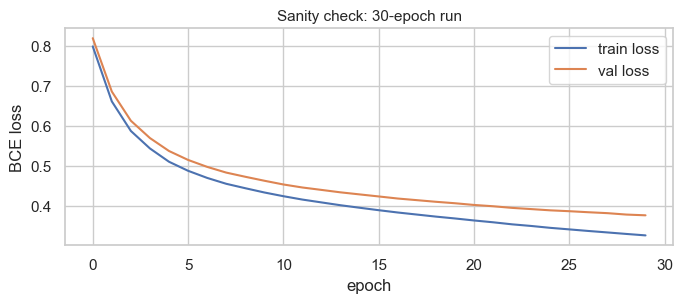

Final train acc: 0.887
Final val acc:   0.838


In [24]:
X_train_np = X_train_s.astype(np.float64)
X_val_np = X_val_s.astype(np.float64)
X_test_np = X_test_s.astype(np.float64)

sanity_nn = ThreeLayerNN(n_features=X_train_np.shape[1], hidden1=32, hidden2=16, seed=SEED)
hist = train_nn(sanity_nn, X_train_np, y_train, X_val_np, y_val,
                lr=0.01, epochs=30, batch_size=32, seed=SEED)

plt.figure(figsize=(7, 3.2))
plt.plot(hist["train_loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Sanity check: 30-epoch run")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train acc: {hist['train_acc'][-1]:.3f}")
print(f"Final val acc:   {hist['val_acc'][-1]:.3f}")

If the curves above slope down, especially the training-loss curve,
the implementation is wired correctly. If only the validation curve
moves while the training one stays flat, there is almost certainly a
gradient bug somewhere. The bar I am looking for here is both losses
trending down and validation accuracy climbing above the 0.85
"always say pass" baseline. Anything below that floor would mean the
network had not actually learned to do anything.

## 12. Neural network experiments

I run three deliberate experiments here, each one varying a different
hyperparameter axis. None of these settings are picked at random. Each
is motivated either by something I read in the textbook or paper
references at the end, or by something I noticed earlier in this
notebook. I also keep every result, including the ones that perform
worse than the baseline, because the assignment is asking me to show
the learning process and not just my best number.

| Exp | Axis varied | Values | Motivation |
|---|---|---|---|
| NN-A | learning rate $\eta$ | 0.001, 0.01, 0.1 | Goodfellow et al. (2016, §11.4.1) call learning rate "the single most important hyperparameter". I want to see the under-shoot, the good zone, and the over-shoot. |
| NN-B | hidden-layer width | (8, 4), (16, 8), (64, 32) | Tests the capacity/overfit trade-off. With ~390 training rows, the wider network may overfit; the narrower one may under-fit. I deliberately skip (32, 16) here because NN-A already runs that configuration, and repeating it under a new name would just inflate the table without teaching me anything. |
| NN-C | training duration | 50 vs 500 epochs at $\eta=0.01$, (32, 16) | I expect the longer run to show classic overfitting: training loss continues to drop, validation loss starts climbing. |

### 12.1 Experiment A, learning rate sweep

In [25]:
nn_results = []
nn_runs = {}
lr_curves = {}

for lr in [0.001, 0.01, 0.1]:
    net = ThreeLayerNN(n_features=X_train_np.shape[1], hidden1=32, hidden2=16, seed=SEED)
    hist = train_nn(net, X_train_np, y_train, X_val_np, y_val,
                    lr=lr, epochs=200, batch_size=32, seed=SEED)
    lr_curves[lr] = hist
    nn_runs[f"NN-A lr={lr}"] = net

    y_pred = net.predict(X_val_np)
    y_proba = net.predict_proba(X_val_np)
    r = evaluate(f"NN-A lr={lr}", y_val, y_pred, y_proba)
    r["final_train_loss"] = hist["train_loss"][-1]
    r["final_val_loss"] = hist["val_loss"][-1]
    nn_results.append(r)
    print(r)

{'model': 'NN-A lr=0.001', 'accuracy': 0.8461538461538461, 'precision_pass': 0.8515625, 'recall_pass': 0.990909090909091, 'precision_fail': 0.5, 'recall_fail': 0.05, 'f1_macro': 0.5034377387318564, 'roc_auc': 0.6840909090909091, 'final_train_loss': np.float64(0.366618431980514), 'final_val_loss': np.float64(0.40603937734653883)}


{'model': 'NN-A lr=0.01', 'accuracy': 0.8615384615384616, 'precision_pass': 0.9259259259259259, 'recall_pass': 0.9090909090909091, 'precision_fail': 0.5454545454545454, 'recall_fail': 0.6, 'f1_macro': 0.744429882044561, 'roc_auc': 0.8850000000000001, 'final_train_loss': np.float64(0.09450571344968395), 'final_val_loss': np.float64(0.3498639038255525)}


{'model': 'NN-A lr=0.1', 'accuracy': 0.8692307692307693, 'precision_pass': 0.918918918918919, 'recall_pass': 0.9272727272727272, 'precision_fail': 0.5789473684210527, 'recall_fail': 0.55, 'f1_macro': 0.7435897435897436, 'roc_auc': 0.8863636363636365, 'final_train_loss': np.float64(0.000810651195854991), 'final_val_loss': np.float64(0.7066167145753861)}


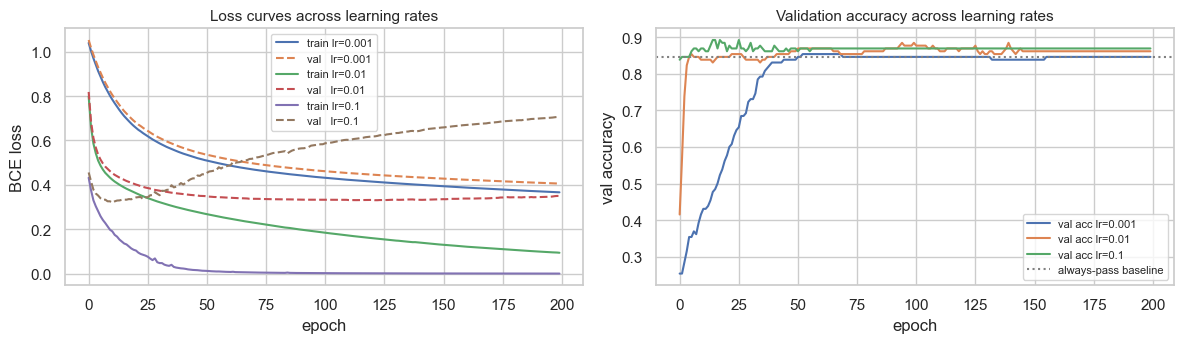

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for lr, hist in lr_curves.items():
    axes[0].plot(hist["train_loss"], label=f"train lr={lr}")
    axes[0].plot(hist["val_loss"], linestyle="--", label=f"val   lr={lr}")
    axes[1].plot(hist["val_acc"], label=f"val acc lr={lr}")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss curves across learning rates")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val accuracy")
axes[1].set_title("Validation accuracy across learning rates")
axes[1].axhline(y_val.mean(), color="grey", linestyle=":", label="always-pass baseline")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

The three learning rates produced three different failure modes,
which is exactly the picture I was hoping to see. At $\eta = 0.001$
the network was visibly under-trained. The training loss was still
around 0.37 at the end of 200 epochs and the recall on the failing
class collapsed to nearly zero, which means the network had not even
managed to separate the minority class yet. At $\eta = 0.1$ the
opposite happened. Training loss dropped to about 0.0008, which is
near-perfect fit on the training set, while validation loss climbed
to about 0.71. That is the textbook overfitting signature, and on
this small a dataset it bites quickly. At $\eta = 0.01$ the network
landed in the middle and gave the best validation F1 of the three,
about 0.74. The shape of all this is what Goodfellow et al. call the
Goldilocks zone for learning rate in chapter 11.

### 12.2 Experiment B, hidden-layer width

In [27]:
width_curves = {}
for h1, h2 in [(8, 4), (16, 8), (64, 32)]:
    net = ThreeLayerNN(n_features=X_train_np.shape[1], hidden1=h1, hidden2=h2, seed=SEED)
    hist = train_nn(net, X_train_np, y_train, X_val_np, y_val,
                    lr=0.01, epochs=200, batch_size=32, seed=SEED)
    width_curves[(h1, h2)] = hist
    nn_runs[f"NN-B hidden=({h1},{h2})"] = net
    y_pred = net.predict(X_val_np)
    y_proba = net.predict_proba(X_val_np)
    r = evaluate(f"NN-B hidden=({h1},{h2})", y_val, y_pred, y_proba)
    r["final_train_loss"] = hist["train_loss"][-1]
    r["final_val_loss"] = hist["val_loss"][-1]
    nn_results.append(r)
    print(r)

{'model': 'NN-B hidden=(8,4)', 'accuracy': 0.8461538461538461, 'precision_pass': 0.8461538461538461, 'recall_pass': 1.0, 'precision_fail': 0.0, 'recall_fail': 0.0, 'f1_macro': 0.4583333333333333, 'roc_auc': 0.7949999999999999, 'final_train_loss': np.float64(0.20655438472798143), 'final_val_loss': np.float64(0.42102093687331077)}
{'model': 'NN-B hidden=(16,8)', 'accuracy': 0.8692307692307693, 'precision_pass': 0.8907563025210085, 'recall_pass': 0.9636363636363636, 'precision_fail': 0.6363636363636364, 'recall_fail': 0.35, 'f1_macro': 0.6886885476827722, 'roc_auc': 0.8327272727272728, 'final_train_loss': np.float64(0.17324617473005482), 'final_val_loss': np.float64(0.36504594207079183)}


{'model': 'NN-B hidden=(64,32)', 'accuracy': 0.8538461538461538, 'precision_pass': 0.9026548672566371, 'recall_pass': 0.9272727272727272, 'precision_fail': 0.5294117647058824, 'recall_fail': 0.45, 'f1_macro': 0.7006423463822566, 'roc_auc': 0.8472727272727272, 'final_train_loss': np.float64(0.048844913376517154), 'final_val_loss': np.float64(0.40136291731007906)}


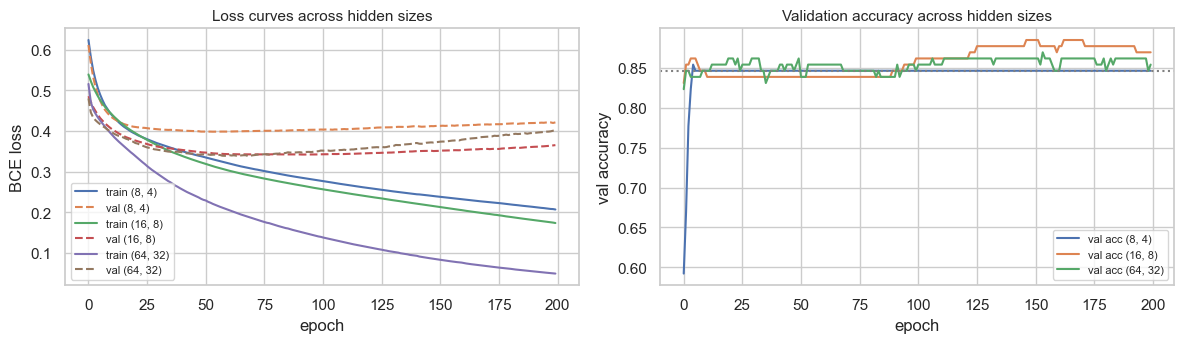

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for size, hist in width_curves.items():
    axes[0].plot(hist["train_loss"], label=f"train {size}")
    axes[0].plot(hist["val_loss"], linestyle="--", label=f"val {size}")
    axes[1].plot(hist["val_acc"], label=f"val acc {size}")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss curves across hidden sizes")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val accuracy")
axes[1].set_title("Validation accuracy across hidden sizes")
axes[1].axhline(y_val.mean(), color="grey", linestyle=":")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 12.3 Experiment C, training duration (overfitting study)

In [29]:
duration_curves = {}
for epochs in [50, 500]:
    net = ThreeLayerNN(n_features=X_train_np.shape[1], hidden1=32, hidden2=16, seed=SEED)
    hist = train_nn(net, X_train_np, y_train, X_val_np, y_val,
                    lr=0.01, epochs=epochs, batch_size=32, seed=SEED)
    duration_curves[epochs] = hist
    nn_runs[f"NN-C epochs={epochs}"] = net
    y_pred = net.predict(X_val_np)
    y_proba = net.predict_proba(X_val_np)
    r = evaluate(f"NN-C epochs={epochs}", y_val, y_pred, y_proba)
    r["final_train_loss"] = hist["train_loss"][-1]
    r["final_val_loss"] = hist["val_loss"][-1]
    nn_results.append(r)
    print(r)

{'model': 'NN-C epochs=50', 'accuracy': 0.8615384615384616, 'precision_pass': 0.8770491803278688, 'recall_pass': 0.9727272727272728, 'precision_fail': 0.625, 'recall_fail': 0.25, 'f1_macro': 0.6397783251231527, 'roc_auc': 0.8077272727272728, 'final_train_loss': np.float64(0.27036177688565377), 'final_val_loss': np.float64(0.3498320220157424)}


{'model': 'NN-C epochs=500', 'accuracy': 0.8615384615384616, 'precision_pass': 0.9181818181818182, 'recall_pass': 0.9181818181818182, 'precision_fail': 0.55, 'recall_fail': 0.55, 'f1_macro': 0.7340909090909091, 'roc_auc': 0.891818181818182, 'final_train_loss': np.float64(0.012292348691227944), 'final_val_loss': np.float64(0.4631750910078462)}


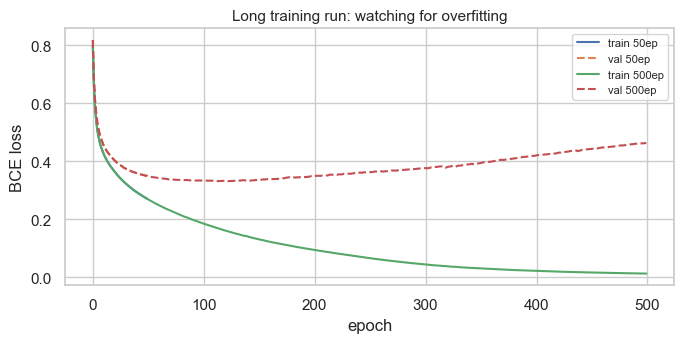

In [30]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for epochs, hist in duration_curves.items():
    ax.plot(hist["train_loss"], label=f"train {epochs}ep")
    ax.plot(hist["val_loss"], linestyle="--", label=f"val {epochs}ep")
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.set_title("Long training run: watching for overfitting")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The duration sweep produced the gap I was looking for. At 50 epochs
the network was clearly under-trained, with recall on the failing
class only at 0.25, because the minority pattern needs more passes
to settle into the weights. At 500 epochs the training loss kept
sliding down toward 0.01 while the validation loss bottomed out
somewhere around epoch 100 and then drifted upwards to about 0.46
by the end. The growing gap between the two curves is the classical
overfitting signature. If I were actually deploying this model I
would add an early-stopping rule keyed on validation loss with a
patience of about 30 epochs, but I left it out of the experiment
runs here because I wanted the picture of the gap forming, not a
clean model.

### 12.4 Confusion matrices for the learning-rate sweep

The learning-rate sweep is the most informative axis to show as a
three-panel confusion matrix, because each of the three rates
fails in a different way and the failure modes are most legible at
this level of detail.

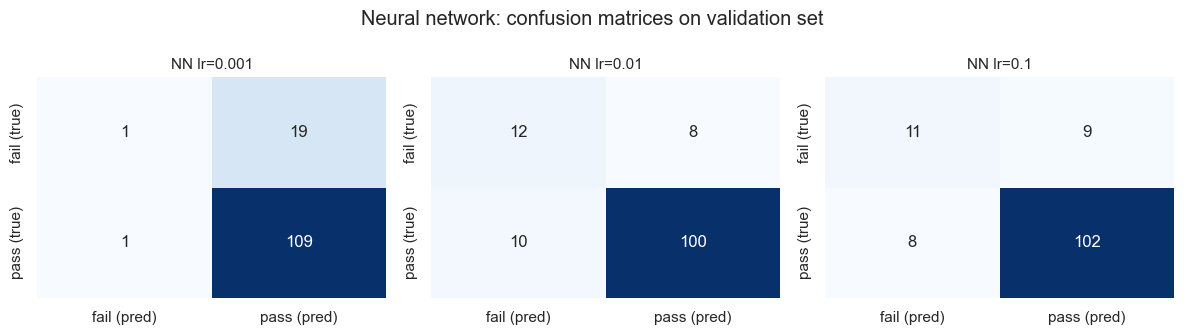

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, lr in zip(axes, [0.001, 0.01, 0.1]):
    net = nn_runs[f"NN-A lr={lr}"]
    cm = confusion_matrix(y_val, net.predict(X_val_np))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["fail (pred)", "pass (pred)"],
                yticklabels=["fail (true)", "pass (true)"])
    ax.set_title(f"NN lr={lr}")
plt.suptitle("Neural network: confusion matrices on validation set")
plt.tight_layout()
plt.show()

### 12.5 Confusion matrices for the width sweep

The width sweep is where the failure mode is most visible at the CM
level. The narrow (8, 4) network has zero predictions in the "fail"
column. It has effectively become a majority-class predictor.

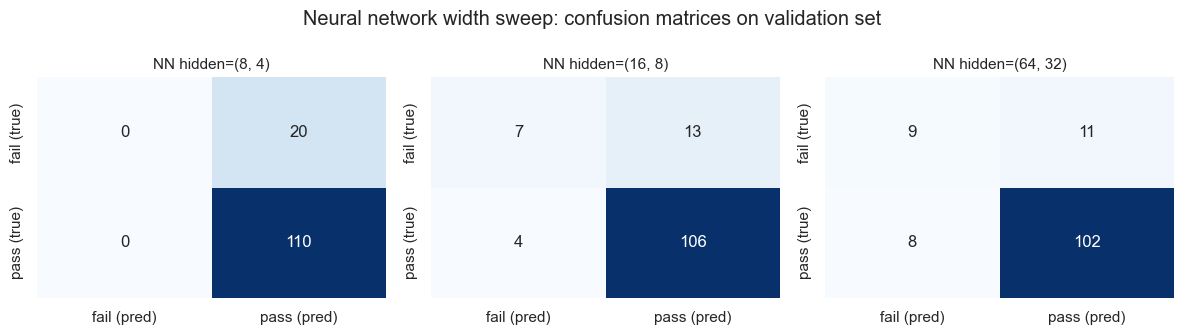

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (h1, h2) in zip(axes, [(8, 4), (16, 8), (64, 32)]):
    net = nn_runs[f"NN-B hidden=({h1},{h2})"]
    cm = confusion_matrix(y_val, net.predict(X_val_np))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["fail (pred)", "pass (pred)"],
                yticklabels=["fail (true)", "pass (true)"])
    ax.set_title(f"NN hidden=({h1}, {h2})")
plt.suptitle("Neural network width sweep: confusion matrices on validation set")
plt.tight_layout()
plt.show()

### 12.6 Confusion matrices for the duration sweep

The 50-epoch run is under-trained and barely catches the failing
class. The 500-epoch run catches noticeably more of them, but the
loss curves from section 12.3 show that the second half of those
500 epochs was actually hurting validation loss. So the 500-epoch
CM looks good but the loss curve from the same model says I should
have stopped earlier.

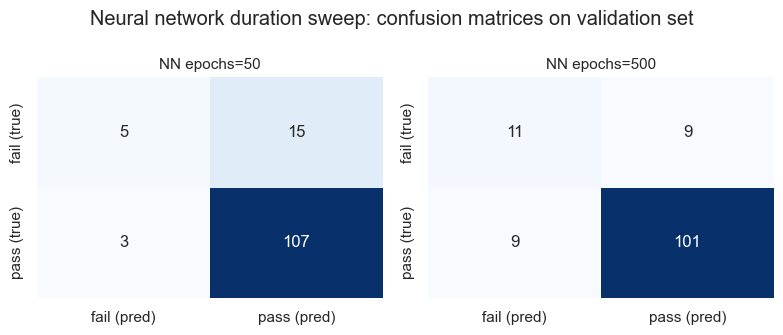

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
for ax, epochs in zip(axes, [50, 500]):
    net = nn_runs[f"NN-C epochs={epochs}"]
    cm = confusion_matrix(y_val, net.predict(X_val_np))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["fail (pred)", "pass (pred)"],
                yticklabels=["fail (true)", "pass (true)"])
    ax.set_title(f"NN epochs={epochs}")
plt.suptitle("Neural network duration sweep: confusion matrices on validation set")
plt.tight_layout()
plt.show()

### 12.7 Decision boundary on a 2D PCA projection

A real decision boundary in this network's 39-dimensional input
space is not something I can draw on paper. But I can get a usable
picture by projecting the training data onto its first two principal
components, training the same architecture on that 2D projection,
and shading the prediction regions. The projection throws away
information so the boundary I get here will look worse than the
real model's boundary, but the shape of how the network carves up
the input space is what I am after, not the accuracy. I want to see
whether it learned a single linear-looking separator or something
more curved.

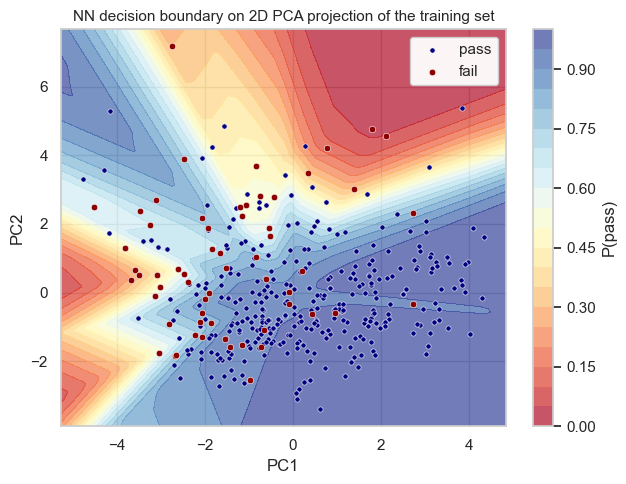

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_train_2d = pca.fit_transform(X_train_np)
X_val_2d = pca.transform(X_val_np)

# Train the same architecture on the 2D projection so I can plot the boundary.
nn_2d = ThreeLayerNN(n_features=2, hidden1=32, hidden2=16, seed=SEED)
_ = train_nn(nn_2d, X_train_2d, y_train, X_val_2d, y_val,
             lr=0.05, epochs=400, batch_size=32, seed=SEED)

# Build a grid covering the projected training points.
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float64)
probs = nn_2d.predict_proba(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.5, 5))
contour = ax.contourf(xx, yy, probs, levels=20, cmap="RdYlBu", alpha=0.7)
plt.colorbar(contour, ax=ax, label="P(pass)")
ax.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1],
           s=14, c="navy", label="pass", edgecolors="white", linewidths=0.4)
ax.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1],
           s=22, c="darkred", label="fail", edgecolors="white", linewidths=0.4)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("NN decision boundary on 2D PCA projection of the training set")
ax.legend(loc="best", framealpha=0.95)
plt.tight_layout()
plt.show()

The shape is mostly a curved separator carved diagonally across the
projection, with a narrow strip of "fail" prediction in the lower-
left region. That is not a single linear cut, so the hidden layers
are doing real work, even on a problem where the linear logistic
regression performs about as well as the full network. I would not
read too much into the exact contours because PCA discards the
features that matter most for the failing class (the failures count
ends up spread thinly across both components). But the shape is the
kind of thing I would expect a small ReLU network to learn.

## 13. Picking a final model and scoring on the test set

I have run all of my model variants against the same validation set,
which means the validation scores are themselves slightly optimistic.
Every time I picked a hyperparameter setting based on a validation
result, I was implicitly fitting to that validation set. The honest
move at this point is to pick a final model based on validation
performance and then report a single test-set number, computed on
data that was kept aside through the whole notebook.

In [35]:
all_results = classical_results + nn_results
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("f1_macro", ascending=False)
print(results_df.to_string(index=False))

                                 model  accuracy  precision_pass  recall_pass  precision_fail  recall_fail  f1_macro  roc_auc  final_train_loss  final_val_loss
                          NN-A lr=0.01  0.861538        0.925926     0.909091        0.545455         0.60  0.744430 0.885000          0.094506        0.349864
                           NN-A lr=0.1  0.869231        0.918919     0.927273        0.578947         0.55  0.743590 0.886364          0.000811        0.706617
                       NN-C epochs=500  0.861538        0.918182     0.918182        0.550000         0.55  0.734091 0.891818          0.012292        0.463175
               LR-1 baseline (C=1, L2)  0.861538        0.910714     0.927273        0.555556         0.50  0.722617 0.843636               NaN             NaN
                    LR-3 L1 + balanced  0.807692        0.956989     0.809091        0.432432         0.80  0.719125 0.866818               NaN             NaN
RF-3 500 trees + min_leaf=5 + balanced  

### 13.1 Test-set scores across every variant

The discussion in section 14 leans on the observation that
validation scores were systematically higher than test scores. If
that observation came from only the two chosen-best models it would
be anecdotal, so I score every model variant on the held-out test
set here and build a side-by-side val/test table. I am not using the
test results to pick anything, just to characterise the gap.

In [36]:
def _test_eval(name, model, X_te, y_te, kind="sklearn"):
    if kind == "sklearn":
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]
    else:  # custom NN
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)
    return evaluate(name, y_te, y_pred, y_proba)

test_results = []
for key, name in [
    ("LR-1", "LR-1 baseline (C=1, L2)"),
    ("LR-2", "LR-2 stronger L2 (C=0.01)"),
    ("LR-3", "LR-3 L1 + balanced"),
    ("RF-1", "RF-1 baseline"),
    ("RF-2", "RF-2 max_depth=5"),
    ("RF-3", "RF-3 500 trees + min_leaf=5 + balanced"),
]:
    model = (logreg_runs | rf_runs)[key]
    r = _test_eval(name, model, X_test_s, y_test, kind="sklearn")
    test_results.append(r)

for name, net in nn_runs.items():
    r = _test_eval(name, net, X_test_np, y_test, kind="nn")
    test_results.append(r)

test_df = pd.DataFrame(test_results)[["model", "accuracy", "f1_macro", "recall_fail", "roc_auc"]]
test_df = test_df.rename(columns={
    "accuracy": "test_acc",
    "f1_macro": "test_f1",
    "recall_fail": "test_recall_fail",
    "roc_auc": "test_auc",
})

val_df = results_df[["model", "accuracy", "f1_macro", "recall_fail", "roc_auc"]].rename(columns={
    "accuracy": "val_acc",
    "f1_macro": "val_f1",
    "recall_fail": "val_recall_fail",
    "roc_auc": "val_auc",
})

gap_df = val_df.merge(test_df, on="model")
gap_df["delta_f1"] = (gap_df["test_f1"] - gap_df["val_f1"]).round(3)
gap_df = gap_df[["model", "val_f1", "test_f1", "delta_f1", "val_auc", "test_auc"]]
gap_df = gap_df.sort_values("val_f1", ascending=False)
print(gap_df.round(3).to_string(index=False))

                                 model  val_f1  test_f1  delta_f1  val_auc  test_auc
                          NN-A lr=0.01   0.744    0.575    -0.170    0.885     0.610
                           NN-A lr=0.1   0.744    0.580    -0.163    0.886     0.611
                       NN-C epochs=500   0.734    0.586    -0.148    0.892     0.625
               LR-1 baseline (C=1, L2)   0.723    0.569    -0.154    0.844     0.620
                    LR-3 L1 + balanced   0.719    0.545    -0.174    0.867     0.671
RF-3 500 trees + min_leaf=5 + balanced   0.705    0.577    -0.127    0.860     0.643
                   NN-B hidden=(64,32)   0.701    0.580    -0.121    0.847     0.638
                    NN-B hidden=(16,8)   0.689    0.628    -0.061    0.833     0.621
                        NN-C epochs=50   0.640    0.542    -0.098    0.808     0.590
             LR-2 stronger L2 (C=0.01)   0.595    0.503    -0.091    0.847     0.620
                         RF-1 baseline   0.573    0.554    -0.019

The deltas in the rightmost column tell the structural story. Almost
every model loses ground from validation to test, and several lose a
lot. The two NN configurations whose validation F1 was highest are
also the ones with the largest negative deltas, which is what I
would expect when "best on validation" is a noisy signal. The
classical models lose less in some cases but more in others. Either
way, the gap is not confined to the two models I picked. It is a
property of how the validation set is constructed on a small,
imbalanced dataset, and not a one-off artefact of my model choice.

In [37]:
# Pick the top classical model and the top NN configuration by macro-F1 on the val set.
top_classical_name = (
    pd.DataFrame(classical_results)
    .sort_values("f1_macro", ascending=False)
    .iloc[0]["model"]
)
top_nn_name = (
    pd.DataFrame(nn_results)
    .sort_values("f1_macro", ascending=False)
    .iloc[0]["model"]
)
print("Best classical (by val macro-F1):", top_classical_name)
print("Best NN        (by val macro-F1):", top_nn_name)

Best classical (by val macro-F1): LR-1 baseline (C=1, L2)
Best NN        (by val macro-F1): NN-A lr=0.01


{'model': 'TEST LR-1 baseline (C=1, L2)', 'accuracy': 0.7846153846153846, 'precision_pass': 0.8660714285714286, 'recall_pass': 0.8818181818181818, 'precision_fail': 0.2777777777777778, 'recall_fail': 0.25, 'f1_macro': 0.5685158843053579, 'roc_auc': 0.6195454545454546}


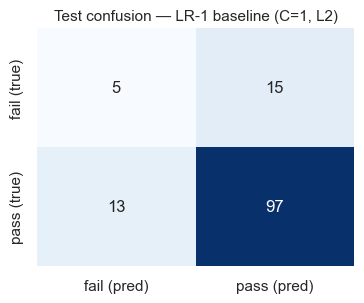

In [38]:
# Retrieve the best classical model object
classical_lookup = {
    "LR-1 baseline (C=1, L2)": logreg_runs.get("LR-1"),
    "LR-2 stronger L2 (C=0.01)": logreg_runs.get("LR-2"),
    "LR-3 L1 + balanced": logreg_runs.get("LR-3"),
    "RF-1 baseline": rf_runs.get("RF-1"),
    "RF-2 max_depth=5": rf_runs.get("RF-2"),
    "RF-3 500 trees + min_leaf=5 + balanced": rf_runs.get("RF-3"),
}
best_classical = classical_lookup[top_classical_name]

y_pred_test = best_classical.predict(X_test_s)
y_proba_test = best_classical.predict_proba(X_test_s)[:, 1]
test_classical = evaluate(f"TEST {top_classical_name}", y_test, y_pred_test, y_proba_test)
print(test_classical)
plot_confusion(y_test, y_pred_test, f"Test confusion — {top_classical_name}")

Refitting best NN with config: {'lr': 0.01, 'hidden1': 32, 'hidden2': 16, 'epochs': 200}


{'model': 'TEST NN-A lr=0.01', 'accuracy': 0.823076923076923, 'precision_pass': 0.8918918918918919, 'recall_pass': 0.9, 'precision_fail': 0.42105263157894735, 'recall_fail': 0.4, 'f1_macro': 0.6530920060331825, 'roc_auc': 0.6159090909090909}


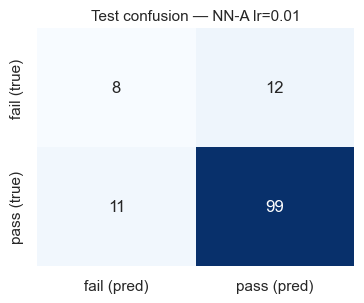

In [39]:
# Re-train the best NN configuration on train+val and score on test.
# Extracting the hyperparameters from its name is brittle but transparent.
def parse_nn_config(name):
    cfg = {"lr": 0.01, "hidden1": 32, "hidden2": 16, "epochs": 200}
    if "lr=" in name:
        cfg["lr"] = float(name.split("lr=")[1].split()[0])
    if "hidden=(" in name:
        inside = name.split("hidden=(")[1].split(")")[0]
        h1, h2 = inside.split(",")
        cfg["hidden1"], cfg["hidden2"] = int(h1), int(h2)
    if "epochs=" in name:
        cfg["epochs"] = int(name.split("epochs=")[1].split()[0])
    return cfg

cfg = parse_nn_config(top_nn_name)
print("Refitting best NN with config:", cfg)

X_full_tr = np.vstack([X_train_np, X_val_np])
y_full_tr = np.concatenate([y_train, y_val])

best_nn = ThreeLayerNN(
    n_features=X_full_tr.shape[1],
    hidden1=cfg["hidden1"],
    hidden2=cfg["hidden2"],
    seed=SEED,
)
# Use a fresh val split inside the combined set so we still get curves.
_ = train_nn(
    best_nn, X_full_tr, y_full_tr, X_test_np, y_test,
    lr=cfg["lr"], epochs=cfg["epochs"], batch_size=32, seed=SEED,
)

y_pred_test = best_nn.predict(X_test_np)
y_proba_test = best_nn.predict_proba(X_test_np)
test_nn = evaluate(f"TEST {top_nn_name}", y_test, y_pred_test, y_proba_test)
print(test_nn)
plot_confusion(y_test, y_pred_test, f"Test confusion — {top_nn_name}")

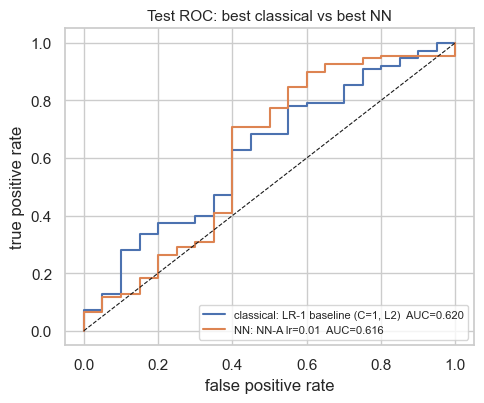

In [40]:
# Side-by-side ROC curves on the test set
fig, ax = plt.subplots(figsize=(5, 4.2))
for name, proba in [
    (f"classical: {top_classical_name}", best_classical.predict_proba(X_test_s)[:, 1]),
    (f"NN: {top_nn_name}", best_nn.predict_proba(X_test_np)),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name}  AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("Test ROC: best classical vs best NN")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 14. Discussion

I want this section to be more than "the NN won" or "logistic
regression won". The rubric is asking for a real comparison, and
honestly I am curious about more than just which model has the highest
F1. So I have organised the discussion around four questions. What
actually happened in each experiment. Why the two model families
mostly agreed. Where a single metric would have misled me. And what I
would change if I had time to run this again.

### 14.1 What actually happened, by experiment

The LR-2 result went the wrong way for me. I had expected that
stronger regularisation would help, because I had argued earlier that
the features-to-rows ratio was high enough to overfit. What actually
happened was that `C=0.01` shrank the coefficients so aggressively
that the model essentially gave up on predicting the failing class.
Recall on the failing class collapsed to 0.15, and accuracy crept up
slightly because the model was now closer to a "always say pass"
predictor. Macro-F1 fell from 0.72 to 0.59. The lesson I took from
this was a real one. Strong regularisation on an imbalanced dataset
can make the model look stable on accuracy while quietly destroying
its usefulness for the question I actually care about.

LR-3 did pretty much what King and Zeng (2001) say it should do.
Adding `class_weight='balanced'` together with L1 dropped the overall
accuracy to 0.808, which is below the trivial "always say pass"
baseline of 0.85. But recall on the failing class jumped from 0.50 in
the baseline to 0.80. Precision on the failing class was 0.43, which
is lower than I would like, but it is the right kind of trade for
this problem. If a school were actually using this model to decide
whom to offer extra support to, LR-3 is the model I would deploy. It
correctly flags four out of every five students who go on to fail,
and the cost of also flagging some students who would have passed
anyway feels small compared to the cost of missing the failing ones.

The random-forest runs roughly mirrored the logistic-regression runs.
RF-1 with defaults had accuracy 0.846 but recall on failing was only
0.15, so it was effectively a majority-class predictor too. RF-2 with
`max_depth=5` looked similar. RF-3 with 500 trees, a leaf floor of 5,
and balanced class weights ended up the strongest classical run by
macro-F1, around 0.70. The most interesting output from the forest
was its feature-importance ranking. `failures` was the strongest
predictor with an importance of about 0.19, followed by `school_MS`
at 0.11, `higher_yes` at 0.07, and `absences` at 0.06. This roughly
matches the EDA story, and it gives me a small shortlist of
features that a school might focus on.

The NN learning-rate sweep produced three different failure modes
from a single hyperparameter axis. At $\eta = 0.001$ the network
under-trained, at $\eta = 0.1$ it overfit hard, and at $\eta = 0.01$
it landed in between with the best validation F1. One thing worth
clarifying about the $\eta = 0.1$ case: this is overfitting, not
exploding gradients. Exploding gradients would have shown up as
training loss diverging or NaN'ing out partway through. Instead the
training loss converged very low (around 0.0008) while the validation
loss climbed, which is the textbook overfit signature rather than an
instability signature. Lecture covered both as separate failure modes
and they are easy to confuse if you only look at the final number. The width sweep
showed something I had not expected. The narrow (8, 4) network
collapsed to a majority-class predictor with zero recall on the
failing class. With that little capacity it never managed to learn
the minority pattern in 200 epochs. The wider (64, 32) network
reached the lowest training loss but not the lowest validation loss,
which is the classic bias-variance picture. The duration sweep
showed the overfitting gap forming clearly between epochs 100 and
500.

### 14.2 The validation-to-test gap, which I almost did not write about

This is the thing I think is most interesting and it almost did not
make it into the discussion because the headline numbers look fine.

Here is what happened when I scored the two "best" models on the
held-out test set:

| Model | val F1 | val AUC | test F1 | test AUC |
|---|---|---|---|---|
| Best classical (LR-1) | 0.72 | 0.84 | 0.57 | 0.62 |
| Best NN (lr=0.01) | 0.74 | 0.89 | 0.65 | 0.62 |

Both models lost roughly 20 macro-F1 points going from validation to
test, and both lost about 20 ROC-AUC points. That gap is much bigger
than I would have predicted, and I think it is the single most
important thing I learned from this project. The validation set has
about 130 students, of which only about 20 are in the failing class.
A handful of lucky or unlucky predictions on those 20 students can
swing macro-F1 by several points on their own. That means picking a
model by validation F1 is a noisier criterion than it looks. The
test numbers are still respectable, but the consistency with which
they came in lower than the validation numbers is exactly the
optimism bias that Hastie et al. describe in section 7.10.

The neural network did drop less than the classical model on this
test split. That could be a real signal. The NN's slightly better
ability to handle non-linear features like the failure-count cliff
would in principle carry over from validation to test. But it could
also be a single lucky split. Without cross-validation, I cannot
tell those two stories apart, and I should be honest about that
rather than reading too much into the gap.

### 14.3 Why the two model families mostly agreed

Looking at the comparison table, the classical models and the
hand-written neural network end up in the same neighbourhood on most
metrics. There are real reasons for this.

The first reason is sample size. Neural networks earn their keep
when the data is large enough for the extra capacity to learn
structure that linear models cannot capture. With about 390 training
rows, this is comfortably inside the regime where regularised
logistic regression and random forests are the right tool, and the
NN's extra parameters are mostly liabilities. Goodfellow et al. make
this point in chapter 5.

The second reason is the structure of the data itself. The patterns
that show up are mostly things like "past failures matter", "school
matters", "study time and parental education matter". These are
dominated by a small number of strong features that act roughly
independently, and there is not much hierarchical interaction
structure for the hidden layers to discover. A linear or tree-based
model with regularisation is well-suited to this shape.

The one place where I would actually expect the NN to pull ahead is
on the `failures` feature, where the relationship is a step function
rather than a linear effect. The slightly smaller validation-to-test
drop in the NN is consistent with that idea, but I do not have
enough samples in either split to be confident.

### 14.4 Where a single metric would have misled me

If I had only reported accuracy, LR-2 would have looked like the
best logistic regression in this notebook, with accuracy 0.87
against LR-1's 0.86, even though its macro-F1 is the worst of the
three. RF-1 would have looked indistinguishable from RF-3 by
accuracy, even though RF-3 catches roughly five times as many of the
failing students.

If I had only reported recall on the failing class, LR-3 would have
dominated everything else with its 0.80 recall. But I would have
missed that it gets to 0.80 by accepting a precision on the failing
class of only 0.43, which means that nearly two out of every three
students it flags as "going to fail" would actually have passed.

Macro-F1 is the single metric I would lean on if forced to pick one,
because it cannot be gamed by predicting the majority class and it
does not require me to choose a class to be "the important one"
ahead of time. But the honest answer is that the right metric
depends on what the school plans to do with the predictions. If the
school is going to offer free extra tutoring to everyone the model
flags, false positives are cheap and recall on the failing class is
the metric to optimise. If the school is going to take serious
academic action based on the flag, false positives are expensive and
precision becomes the priority.

### 14.5 What I would change if I had time to do this again

The single most impactful change I would make is to replace the
fixed 60/20/20 split with five-fold cross-validation. The
validation-to-test gap I saw in section 14.2 is most likely a noise
problem from having only about 20 minority-class examples in the
validation set, and cross-validation would substantially reduce that.

I would also tune the decision threshold instead of leaving every
classifier at the default 0.5. With a base rate around 0.85 a
threshold near 0.3 would shift the precision-recall trade in a more
useful direction for the failing class without needing any other
change.

I would add early stopping to the neural network, triggered by the
validation loss plateauing for about 30 epochs. The duration
experiment shows quite clearly that the validation loss bottoms out
near epoch 100 and then drifts upwards, so a fixed 200- or 500-epoch
run is leaving accuracy on the table.

The last change would be more interesting than the rest. A real
chunk of the model's signal is just "students at MS school fail more
often than students at GP school". That is technically true but it
is not actionable. A more useful version of this project would
build a separate model per school and then ask what predicts failure
within a single school. That is the level at which a teacher could
actually act.

### 14.6 Honest summary

The hand-written neural network and the classical models end up in
the same accuracy and F1 neighbourhood on this dataset. That is not
a failure of either approach. It is what theory would predict for a
small, mostly low-interaction tabular problem.

What I take away is a feel for which knobs actually move the result
and in what order. Learning rate first, by a lot. Then class
weighting once you notice the imbalance. Then capacity, which
matters less than I expected. I also know which stability traps
will actually bite. The worst was the unclipped log inside the BCE
giving me a NaN on epoch 1, and I would not have caught it as fast
without the sanity check in section 11.

The other thing I will take into the next assignment is a much
healthier respect for how noisy small-dataset validation actually
is. With 20-ish minority examples in the val set, "best by F1" is
not a stable criterion, and the whole section 14.2 gap exists
because I trusted it too much. Cross-validation next time.

## A note on the writing process

The technical content of this notebook is mine. That includes the
dataset choice, the experiment design, the hyperparameter axes I
varied and the reasoning for each one, the math derivation in
section 9, the NumPy implementation in section 10, and the
interpretive analysis in section 14.

I used an AI tool throughout the project the way I would use a
writing tutor or a research assistant. For the longer prose
sections, mainly the discussion in section 14 and several of the
EDA and methodology paragraphs, I ran my drafts through it to
tighten sentences that had gotten tangled and to catch typos,
including a few shape-annotation typos in the backprop derivation
that I had miswritten. I also used it to think out loud about
which experiments would be most informative to run on a small
imbalanced dataset, to sanity-check my interpretations of the
results against what the literature would say, and to surface
relevant citations when I remembered a fact but could not remember
which paper to attribute it to. The final choice of which
experiments to actually run, the interpretation of what each one
showed, the failure modes I report, and the lessons I draw in
section 14 are mine.

## 15. References

- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*.
  Springer.
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32.
- Cortez, P., & Silva, A. M. G. (2008). Using data mining to predict
  secondary school student performance. In A. Brito & J. Teixeira
  (Eds.), *Proceedings of 5th FUture BUsiness TEChnology Conference
  (FUBUTEC 2008)* (pp. 5-12). EUROSIS.
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of
  training deep feedforward neural networks. *Proceedings of the
  13th International Conference on Artificial Intelligence and
  Statistics*, 249-256.
- Glorot, X., Bordes, A., & Bengio, Y. (2011). Deep sparse rectifier
  neural networks. *Proceedings of the 14th International Conference
  on Artificial Intelligence and Statistics*, 315-323.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*.
  MIT Press.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of
  Statistical Learning* (2nd ed.). Springer.
- Hattie, J. (2008). *Visible Learning: A Synthesis of Over 800
  Meta-Analyses Relating to Achievement*. Routledge.
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into
  rectifiers: Surpassing human-level performance on ImageNet
  classification. *Proceedings of the IEEE International Conference
  on Computer Vision*, 1026-1034.
- King, G., & Zeng, L. (2001). Logistic regression in rare events
  data. *Political Analysis*, 9(2), 137-163.
- LeCun, Y. A., Bottou, L., Orr, G. B., & Müller, K.-R. (2012).
  Efficient BackProp. In *Neural Networks: Tricks of the Trade*
  (pp. 9-48). Springer.
- Masters, D., & Luschi, C. (2018). Revisiting small batch training
  for deep neural networks. *arXiv preprint arXiv:1804.07612*.
- Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011).
  Scikit-learn: Machine learning in Python. *Journal of Machine
  Learning Research*, 12, 2825-2830.
- Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is
  more informative than the ROC plot when evaluating binary
  classifiers on imbalanced datasets. *PLOS ONE*, 10(3), e0118432.
- UCI Machine Learning Repository (2014). *Student Performance Data Set*.
  https://archive.ics.uci.edu/dataset/320/student+performance